<a href="https://colab.research.google.com/github/abudofa2017-lgtm/Pharmacovigilance-data-practice-/blob/main/Machine_Learning_Class_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Abasiama Udofa**
**SCA/APC3/DS/064**

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler  # We'll keep this ready for scaling

# Setting plot style for better visuals
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Loading the dataset
df = pd.read_csv('advertising.csv')

# Display the first few rows to verify the data
print("First 5 rows of the dataset:")
df.head()

In [ ]:
# Check the shape and basic info
print("\nShape of the dataset (rows, columns):", df.shape)
print("\nColumn information:")
df.info()
df.describe()


Shape of the dataset (rows, columns): (4546, 5)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4546 entries, 0 to 4545
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   tv            4546 non-null   float64
 1   radio         4546 non-null   float64
 2   social_media  4546 non-null   float64
 3   influencer    4546 non-null   object 
 4   sales         4546 non-null   float64
dtypes: float64(4), object(1)
memory usage: 177.7+ KB


,tv,radio,social_media,sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54062.912451,18157.533110,3323.472829,192413.332112
std,26104.941838,9663.259642,2211.253915,93019.873216
min,10000.000000,0.680000,0.030000,31199.410000
25%,32000.000000,10555.355000,1530.822500,112434.610000
50%,53000.000000,17859.515000,3055.565000,188963.680000
75%,77000.000000,25640.605000,4804.922500,272324.240000
max,100000.000000,48871.160000,13981.660000,364079.750000


In [ ]:
# Create feature matrix X (tv) and target vector y (sales)
x = df[['tv']]           # Feature: tv advertising budget (in thousands of dollars)
y = df['sales']          # Target: Sales (in thousands of units)

# Since we are using a single feature, no scaling is strictly necessary.
# However, for future reference, here is how we would scale:
# scaler = StandardScaler()
# x_scaled = scaler.fit_transform(X)

print("Feature (x) shape:", x.shape)
print("Target (y) shape:", y.shape)

Feature (x) shape: (4546, 1)
Target (y) shape: (4546,)


In [ ]:
# Split the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

# Print the sizes to verify
print("Training set size:", x_train.shape[0])
print("Test set size:", x_test.shape[0])

Training set size: 3636
Test set size: 910


In [ ]:
# Instantiate the KNN regressor with k=5
knn_model = KNeighborsRegressor(n_neighbors=5)

# Fit the model to the training data (learn from the training set)
knn_model.fit(x_train, y_train)

# Predict sales on the test set
y_pred = knn_model.predict(x_test)

# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("KNN with k=5")
print("Mean Squared Error (MSE):", round(mse, 2))
print("R-squared (R²):", round(r2, 2))

KNN with k=5
Mean Squared Error (MSE): 10317124.51
R-squared (R²): 1.0


In [ ]:
# Define a range of k values to test (odd numbers to avoid ties)
k_values = range(1, 20, 2)

# Lists to store scores
train_mse_list = []
test_mse_list = []
train_r2_list = []
test_r2_list = []

for k in k_values:
    # Create and train the model
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on both sets
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Compute metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

# Create a summary DataFrame
results_df = pd.DataFrame({
    'k': k_values,
    'Train MSE': train_mse_list,
    'Test MSE': test_mse_list,
    'Train R²': train_r2_list,
    'Test R²': test_r2_list
})

print("Model performance for different k values:")
results_df

Model performance for different k values:


,k,Train MSE,Test MSE,Train R²,Test R²
0,1,1.554765e+07,1.633135e+07,0.998215,0.998058
1,3,1.095755e+07,1.135526e+07,0.998742,0.998650
2,5,1.007700e+07,1.031712e+07,0.998843,0.998773
3,7,9.686908e+06,9.758892e+06,0.998888,0.998840
4,9,9.306898e+06,9.404831e+06,0.998932,0.998882
5,11,9.137250e+06,9.259185e+06,0.998951,0.998899
6,13,8.977512e+06,9.133492e+06,0.998969,0.998914
7,15,8.872691e+06,9.011490e+06,0.998981,0.998929
8,17,8.823641e+06,8.934426e+06,0.998987,0.998938
9,19,8.763929e+06,8.862100e+06,0.998994,0.998946


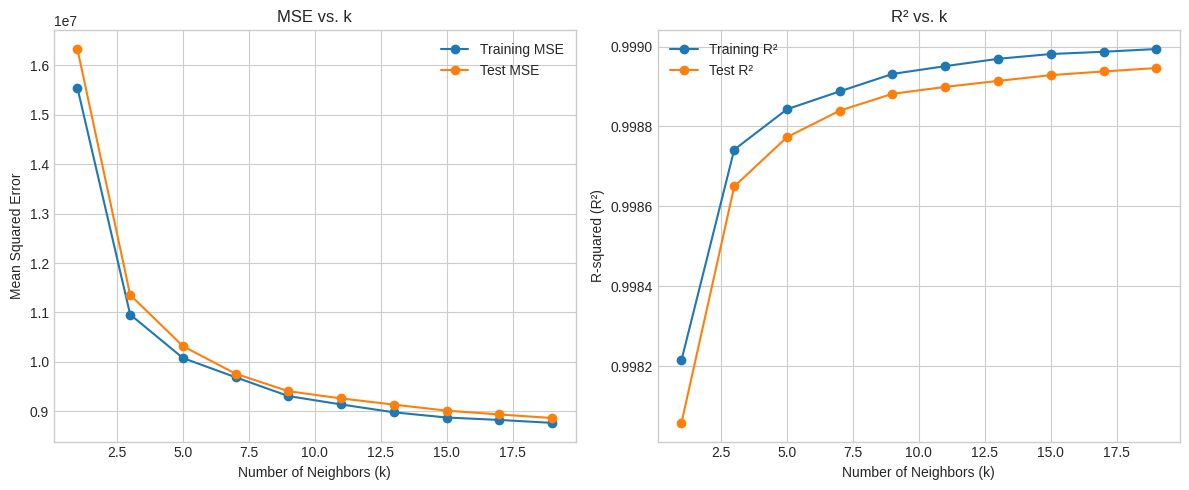

In [ ]:
# Plot MSE vs k (lower is better)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, train_mse_list, label='Training MSE', marker='o')
plt.plot(k_values, test_mse_list, label='Test MSE', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs. k')
plt.legend()
plt.grid(True)

# Plot R² vs k (higher is better)
plt.subplot(1, 2, 2)
plt.plot(k_values, train_r2_list, label='Training R²', marker='o')
plt.plot(k_values, test_r2_list, label='Test R²', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R-squared (R²)')
plt.title('R² vs. k')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Select all three features as predictors
x_multi = df[['tv', 'radio', 'social_media']]
y_multi = df['sales']

# Split the multi‑feature data
x_train_multi, x_test_multi, y_train_multi, y_test_multi = train_test_split(x_multi, y_multi, test_size=0.2, random_state=42)

# Standardise the features (important for KNN)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_multi)
x_test_scaled = scaler.transform(x_test_multi)

# Train a KNN model with k=5 on the scaled data
knn_multi = KNeighborsRegressor(n_neighbors=5)
knn_multi.fit(x_train_scaled, y_train_multi)

# Predict and evaluate
y_pred_multi = knn_multi.predict(x_test_scaled)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("Multi‑feature KNN (k=5) with scaling")
print("Mean Squared Error (MSE):", round(mse_multi, 2))
print("R-squared (R²):", round(r2_multi, 2))

Multi‑feature KNN (k=5) with scaling
Mean Squared Error (MSE): 34580837.58
R-squared (R²): 1.0
